In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv("licm-eval.csv")
df

,benchmark,run,result
0,quadratic,baseline,785
1,quadratic,to_from_ssa,5139
2,quadratic,to_from_ssa_opt,4845
3,quadratic,to_from_ssa_opt_licm,1579
4,primes-between,baseline,574100
...,...,...,...
151,fizz-buzz,to_from_ssa_opt_licm,incorrect
152,bitwise-ops,baseline,1690
153,bitwise-ops,to_from_ssa,6856
154,bitwise-ops,to_from_ssa_opt,6856


In [45]:
bad_benches = df["benchmark"][df["result"].apply(lambda x: x.lower().strip() == "incorrect" or x.lower().strip() == "timeout")]
new_df = []
for c, row in df.iterrows():
    if row["benchmark"].lower() not in list(bad_benches):
        new_df.append(row)
        
df = pd.DataFrame(new_df)

In [46]:
df["result"] = df["result"].astype(int)

In [47]:
df['normalized_result'] = df['result'] / df.groupby('benchmark')['result'].transform('first')

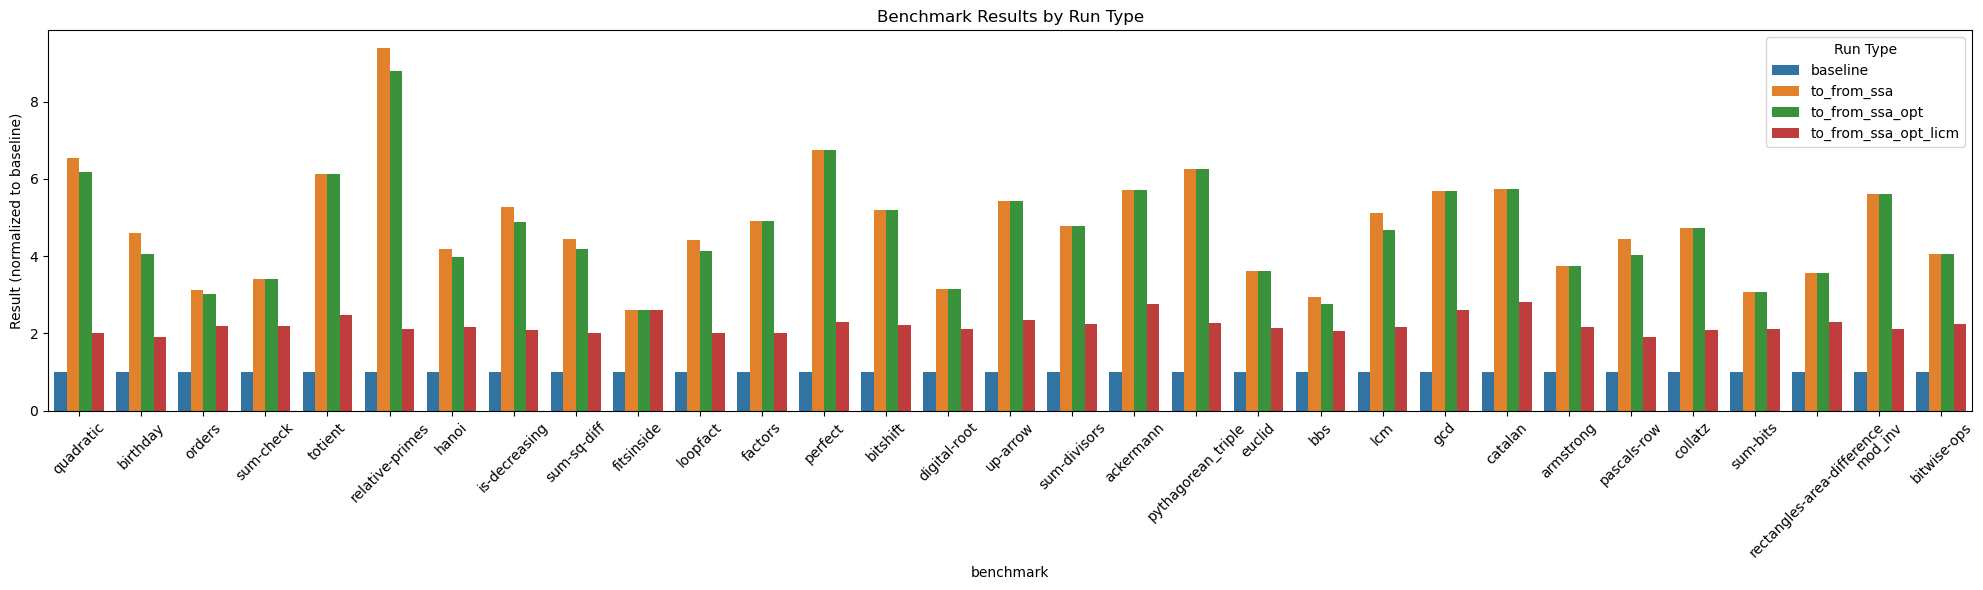

In [48]:
plt.figure(figsize=(20, 6))
sns.barplot(x='benchmark', y='normalized_result', hue='run', data=df)
plt.title('Benchmark Results by Run Type')
plt.ylabel('Result (normalized to baseline)')
plt.xticks(rotation=45)
plt.legend(title='Run Type')
plt.tight_layout()
plt.show()

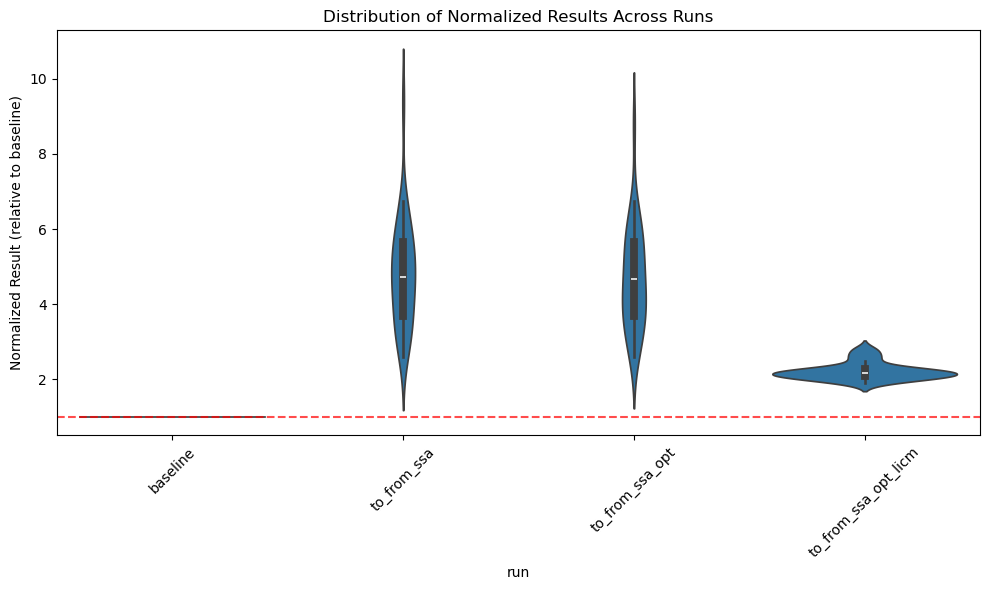

In [49]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='run', y='normalized_result', data=df)
plt.axhline(y=1, color='r', linestyle='--', alpha=0.7)
plt.ylabel('Normalized Result (relative to baseline)')
plt.title('Distribution of Normalized Results Across Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
df

,benchmark,run,result,normalized_result
0,quadratic,baseline,785,1.000000
1,quadratic,to_from_ssa,5139,6.546497
2,quadratic,to_from_ssa_opt,4845,6.171975
3,quadratic,to_from_ssa_opt_licm,1579,2.011465
8,birthday,baseline,484,1.000000
...,...,...,...,...
143,mod_inv,to_from_ssa_opt_licm,1175,2.105735
152,bitwise-ops,baseline,1690,1.000000
153,bitwise-ops,to_from_ssa,6856,4.056805
154,bitwise-ops,to_from_ssa_opt,6856,4.056805
